# Exponential Family Distributions

A comprehensive exploration of exponential family distributions, their properties, and applications in machine learning.

## 1. Import Required Libraries

Import necessary libraries including NumPy, SciPy, Matplotlib, and Pandas for implementing exponential family distributions.

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

## 2. Understanding the Exponential Family Form

The canonical form of exponential family distributions is:

$$p(x|\eta) = h(x) \exp(\eta^T T(x) - A(\eta))$$

Where:
- $\eta$ is the **natural parameter** (or canonical parameter)
- $T(x)$ is the **sufficient statistic**
- $A(\eta)$ is the **log-partition function** (normalizing constant)
- $h(x)$ is the base measure (often just 1)

Any distribution that can be written in this form is a member of the exponential family. This form is extremely useful because:
1. It provides a unified framework for many common distributions
2. The sufficient statistics completely summarize the data for parameter estimation
3. The log-partition function encodes all the distribution's moments

In [14]:
print("Examples: Common Distributions as Exponential Families")
print("=" * 60)

# Example 1: Bernoulli Distribution
print("\n1. BERNOULLI DISTRIBUTION")
print("-" * 60)
print("Bernoulli(p) with p ∈ (0,1)")
print("\nCanonical Form:")
print("  η = log(p/(1-p))  [logit of p]")
print("  T(x) = x  [the observation itself]")
print("  A(η) = log(1 + exp(η))  [log-partition]")
print("  h(x) = 1")
print("\nVerification: p(x|p) = p^x (1-p)^(1-x)")
print("           = exp[x·log(p/(1-p)) + log(1-p)]")
print("           = exp[η·x - log(1 + exp(η))]")
print("           = h(x)·exp(η^T T(x) - A(η)) ✓")

# Example 2: Gaussian Distribution
print("\n2. GAUSSIAN DISTRIBUTION (univariate)")
print("-" * 60)
print("N(μ, σ²) with fixed variance σ²")
print("\nCanonical Form (treating σ² as fixed):")
print("  η = μ/σ²")
print("  T(x) = x")
print("  A(η) = μ²/(2σ²) = (η·σ²)²/(2σ²)")
print("  h(x) = (2πσ²)^(-1/2)·exp(-x²/(2σ²))")

# Example 3: Poisson Distribution
print("\n3. POISSON DISTRIBUTION")
print("-" * 60)
print("Poisson(λ) with λ > 0")
print("\nCanonical Form:")
print("  η = log(λ)  [log of rate]")
print("  T(x) = x")
print("  A(η) = exp(η) = λ")
print("  h(x) = 1/x!")

# Example 4: Exponential Distribution
print("\n4. EXPONENTIAL DISTRIBUTION")
print("-" * 60)
print("Exp(λ) with λ > 0 (rate parameterization)")
print("\nCanonical Form:")
print("  η = -λ  [negative rate]")
print("  T(x) = x")
print("  A(η) = -log(-η) = -log(λ)")
print("  h(x) = 1  (for x > 0)")


Examples: Common Distributions as Exponential Families

1. BERNOULLI DISTRIBUTION
------------------------------------------------------------
Bernoulli(p) with p ∈ (0,1)

Canonical Form:
  η = log(p/(1-p))  [logit of p]
  T(x) = x  [the observation itself]
  A(η) = log(1 + exp(η))  [log-partition]
  h(x) = 1

Verification: p(x|p) = p^x (1-p)^(1-x)
           = exp[x·log(p/(1-p)) + log(1-p)]
           = exp[η·x - log(1 + exp(η))]
           = h(x)·exp(η^T T(x) - A(η)) ✓

2. GAUSSIAN DISTRIBUTION (univariate)
------------------------------------------------------------
N(μ, σ²) with fixed variance σ²

Canonical Form (treating σ² as fixed):
  η = μ/σ²
  T(x) = x
  A(η) = μ²/(2σ²) = (η·σ²)²/(2σ²)
  h(x) = (2πσ²)^(-1/2)·exp(-x²/(2σ²))

3. POISSON DISTRIBUTION
------------------------------------------------------------
Poisson(λ) with λ > 0

Canonical Form:
  η = log(λ)  [log of rate]
  T(x) = x
  A(η) = exp(η) = λ
  h(x) = 1/x!

4. EXPONENTIAL DISTRIBUTION
-------------------------------

## 3. Natural Parameters and Sufficient Statistics

### Natural Parameters ($\eta$)
The natural parameter directly appears in the exponential family form. It's different from the conventional parameters we usually use (like $\mu$ and $\sigma$ for Gaussian). The relationship between natural and conventional parameters encodes important information about the distribution.

### Sufficient Statistics ($T(x)$)
A sufficient statistic contains all the information in the data relevant to the parameters. For exponential families:
- For i.i.d. samples $x_1, \ldots, x_n$, the sufficient statistic is $\sum_i T(x_i)$
- This means the full dataset can be summarized by just these statistics for parameter estimation
- Maximum likelihood estimation depends only on $\sum T(x_i)$, not on the individual data points

### Key Relationships
For an exponential family distribution, the moments can be derived from the log-partition function:
- $E[T(x)] = \nabla A(\eta)$ (mean of the sufficient statistic)
- $\text{Var}[T(x)] = \nabla^2 A(\eta)$ (variance of the sufficient statistic)

In [15]:
# Demonstrating Natural Parameters and Sufficient Statistics

class ExponentialFamilyExample:
    """Base class for exponential family examples"""
    
    def __init__(self, name):
        self.name = name
    
    def log_partition(self, eta):
        """Compute A(η)"""
        raise NotImplementedError
    
    def sufficient_stat(self, x):
        """Compute T(x)"""
        raise NotImplementedError
    
    def mean_from_log_partition(self, eta):
        """E[T(x)] = ∇A(η) computed numerically"""
        eps = 1e-5
        grad = np.zeros_like(eta)
        for i in range(len(eta)):
            eta_plus = eta.copy()
            eta_plus[i] += eps
            eta_minus = eta.copy()
            eta_minus[i] -= eps
            grad[i] = (self.log_partition(eta_plus) - 
                      self.log_partition(eta_minus)) / (2 * eps)
        return grad

class BernoulliExponentialFamily(ExponentialFamilyExample):
    """Bernoulli distribution as exponential family"""
    
    def __init__(self):
        super().__init__("Bernoulli")
    
    def log_partition(self, eta):
        """A(η) = log(1 + exp(η))"""
        return np.log(1 + np.exp(eta))
    
    def sufficient_stat(self, x):
        """T(x) = x (the observation)"""
        return x
    
    def eta_from_p(self, p):
        """Convert probability p to natural parameter η"""
        return np.log(p / (1 - p))
    
    def p_from_eta(self, eta):
        """Convert natural parameter η to probability p"""
        return 1 / (1 + np.exp(-eta))

# Example: Bernoulli with p = 0.7
print("BERNOULLI EXPONENTIAL FAMILY EXAMPLE")
print("=" * 60)
bern = BernoulliExponentialFamily()
p = 0.7
eta = bern.eta_from_p(p)
print(f"\nProbability p = {p}")
print(f"Natural parameter η = log(p/(1-p)) = {eta:.4f}")
print(f"\nLog-partition A(η) = log(1 + exp(η)) = {bern.log_partition(eta):.4f}")

mean_from_gradient = bern.mean_from_log_partition(np.array([eta]))[0]
print(f"\nMean E[T(x)] = E[x] = {mean_from_gradient:.4f}")
print(f"Theoretical mean (should equal p) = {p:.4f}")

# Generate samples and compute sufficient statistic
samples = np.random.binomial(1, p, size=100)
sufficient_stat_sum = np.sum(samples)
print(f"\nSufficient statistic for 100 samples:")
print(f"  Sum of T(x_i) = Σx_i = {sufficient_stat_sum}")
print(f"  Empirical mean = {sufficient_stat_sum/100:.4f}")

class PoissonExponentialFamily(ExponentialFamilyExample):
    """Poisson distribution as exponential family"""
    
    def __init__(self):
        super().__init__("Poisson")
    
    def log_partition(self, eta):
        """A(η) = exp(η)"""
        return np.exp(eta)
    
    def sufficient_stat(self, x):
        """T(x) = x (the observation)"""
        return x
    
    def eta_from_lambda(self, lam):
        """Convert rate λ to natural parameter η = log(λ)"""
        return np.log(lam)
    
    def lambda_from_eta(self, eta):
        """Convert natural parameter to rate λ = exp(η)"""
        return np.exp(eta)

# Example: Poisson with λ = 3
print("\n\nPOISSON EXPONENTIAL FAMILY EXAMPLE")
print("=" * 60)
poisson = PoissonExponentialFamily()
lam = 3.0
eta_poisson = poisson.eta_from_lambda(lam)
print(f"\nRate λ = {lam}")
print(f"Natural parameter η = log(λ) = {eta_poisson:.4f}")
print(f"\nLog-partition A(η) = exp(η) = {poisson.log_partition(eta_poisson):.4f}")

mean_poisson = poisson.mean_from_log_partition(np.array([eta_poisson]))[0]
print(f"\nMean E[T(x)] = E[x] = {mean_poisson:.4f}")
print(f"Theoretical mean (should equal λ) = {lam:.4f}")

# Generate samples
poisson_samples = np.random.poisson(lam, size=100)
print(f"\nSufficient statistic for 100 samples:")
print(f"  Sum of T(x_i) = Σx_i = {np.sum(poisson_samples)}")
print(f"  Empirical mean = {np.mean(poisson_samples):.4f}")


BERNOULLI EXPONENTIAL FAMILY EXAMPLE

Probability p = 0.7
Natural parameter η = log(p/(1-p)) = 0.8473

Log-partition A(η) = log(1 + exp(η)) = 1.2040

Mean E[T(x)] = E[x] = 0.7000
Theoretical mean (should equal p) = 0.7000

Sufficient statistic for 100 samples:
  Sum of T(x_i) = Σx_i = 70
  Empirical mean = 0.7000


POISSON EXPONENTIAL FAMILY EXAMPLE

Rate λ = 3.0
Natural parameter η = log(λ) = 1.0986

Log-partition A(η) = exp(η) = 3.0000

Mean E[T(x)] = E[x] = 3.0000
Theoretical mean (should equal λ) = 3.0000

Sufficient statistic for 100 samples:
  Sum of T(x_i) = Σx_i = 296
  Empirical mean = 2.9600


## 4. Common Exponential Family Distributions

The exponential family includes many commonly used distributions. Below we implement several of them in canonical form.

In [16]:
# Implementation of common exponential family distributions

class GaussianExponentialFamily(ExponentialFamilyExample):
    """Univariate Gaussian with fixed variance"""
    
    def __init__(self, sigma_sq=1.0):
        super().__init__("Gaussian (fixed σ²)")
        self.sigma_sq = sigma_sq
    
    def log_partition(self, eta):
        """A(η) = η²σ²/2"""
        return eta**2 * self.sigma_sq / 2
    
    def sufficient_stat(self, x):
        """T(x) = x"""
        return x
    
    def eta_from_mu(self, mu):
        """η = μ/σ²"""
        return mu / self.sigma_sq
    
    def mu_from_eta(self, eta):
        """μ = η·σ²"""
        return eta * self.sigma_sq

class ExponentialDistribution(ExponentialFamilyExample):
    """Exponential distribution"""
    
    def __init__(self):
        super().__init__("Exponential")
    
    def log_partition(self, eta):
        """A(η) = -log(-η) for η < 0"""
        return -np.log(-eta)
    
    def sufficient_stat(self, x):
        """T(x) = x"""
        return x
    
    def eta_from_rate(self, rate):
        """η = -rate"""
        return -rate
    
    def rate_from_eta(self, eta):
        """rate = -η"""
        return -eta

# Create summary table
print("\nSUMMARY TABLE: Common Exponential Family Distributions")
print("=" * 80)

distributions_info = [
    {
        'Distribution': 'Bernoulli(p)',
        'Natural Param η': 'log(p/(1-p))',
        'Sufficient Stat T(x)': 'x',
        'Log-partition A(η)': 'log(1 + exp(η))',
        'Mean of T(x)': '1/(1 + exp(-η))',
        'Variance of T(x)': 'exp(η)/(1+exp(η))²'
    },
    {
        'Distribution': 'Poisson(λ)',
        'Natural Param η': 'log(λ)',
        'Sufficient Stat T(x)': 'x',
        'Log-partition A(η)': 'exp(η)',
        'Mean of T(x)': 'exp(η)',
        'Variance of T(x)': 'exp(η)'
    },
    {
        'Distribution': 'Gaussian(μ, σ²)',
        'Natural Param η': 'μ/σ²',
        'Sufficient Stat T(x)': 'x',
        'Log-partition A(η)': 'η²σ²/2',
        'Mean of T(x)': 'η·σ²',
        'Variance of T(x)': 'σ²'
    },
    {
        'Distribution': 'Exponential(λ)',
        'Natural Param η': '-λ',
        'Sufficient Stat T(x)': 'x',
        'Log-partition A(η)': '-log(-η)',
        'Mean of T(x)': '-1/η',
        'Variance of T(x)': '1/η²'
    }
]

df_dists = pd.DataFrame(distributions_info)
print(df_dists.to_string(index=False))

# Numerical Examples
print("\n\nNUMERICAL EXAMPLES")
print("=" * 80)

# Gaussian example
print("\n1. GAUSSIAN DISTRIBUTION with σ² = 1")
print("-" * 80)
gauss = GaussianExponentialFamily(sigma_sq=1.0)
mu_gauss = 2.0
eta_gauss = gauss.eta_from_mu(mu_gauss)
print(f"Mean μ = {mu_gauss}")
print(f"Natural parameter η = μ/σ² = {eta_gauss:.4f}")
print(f"Log-partition A(η) = η²/2 = {gauss.log_partition(eta_gauss):.4f}")
mean_recovered = gauss.mean_from_log_partition(np.array([eta_gauss]))[0]
print(f"Recovered mean from A'(η) = {mean_recovered:.4f}")

# Exponential example
print("\n2. EXPONENTIAL DISTRIBUTION")
print("-" * 80)
exp_dist = ExponentialDistribution()
rate = 0.5
eta_exp = exp_dist.eta_from_rate(rate)
print(f"Rate λ = {rate}")
print(f"Natural parameter η = -λ = {eta_exp:.4f}")
print(f"Log-partition A(η) = -log(-η) = {exp_dist.log_partition(eta_exp):.4f}")
mean_exp = exp_dist.mean_from_log_partition(np.array([eta_exp]))[0]
print(f"Recovered mean from A'(η) = {mean_exp:.4f}")
print(f"Expected mean (1/λ) = {1/rate:.4f}")



SUMMARY TABLE: Common Exponential Family Distributions
   Distribution Natural Param η Sufficient Stat T(x) Log-partition A(η)    Mean of T(x)   Variance of T(x)
   Bernoulli(p)    log(p/(1-p))                    x    log(1 + exp(η)) 1/(1 + exp(-η)) exp(η)/(1+exp(η))²
     Poisson(λ)          log(λ)                    x             exp(η)          exp(η)             exp(η)
Gaussian(μ, σ²)            μ/σ²                    x             η²σ²/2            η·σ²                 σ²
 Exponential(λ)              -λ                    x           -log(-η)            -1/η               1/η²


NUMERICAL EXAMPLES

1. GAUSSIAN DISTRIBUTION with σ² = 1
--------------------------------------------------------------------------------
Mean μ = 2.0
Natural parameter η = μ/σ² = 2.0000
Log-partition A(η) = η²/2 = 2.0000
Recovered mean from A'(η) = 2.0000

2. EXPONENTIAL DISTRIBUTION
--------------------------------------------------------------------------------
Rate λ = 0.5
Natural parameter η = -λ = 

## 5. Deriving Mean and Variance

One of the most powerful properties of exponential families is that all moments can be derived from the log-partition function $A(\eta)$:

$$E[T(x)] = \nabla A(\eta) = \frac{\partial A(\eta)}{\partial \eta}$$

$$\text{Var}[T(x)] = \nabla^2 A(\eta) = \frac{\partial^2 A(\eta)}{\partial \eta^2}$$

This is a remarkable result because:
1. It shows that the log-partition function completely encodes all distribution properties
2. Computing derivatives of $A(\eta)$ gives us the moments without needing to compute integrals
3. It provides a way to design new distributions by specifying an appropriate $A(\eta)$

### Derivation Sketch
For the exponential family $p(x|\eta) = h(x)\exp(\eta^T T(x) - A(\eta))$, normalization requires:

$$\int p(x|\eta) dx = 1$$

Taking the derivative with respect to $\eta$ and using the chain rule leads to:

$$E[T(x)] = \nabla A(\eta)$$

Similarly, taking the second derivative gives the variance formula.

In [17]:
# Numerical computation of mean and variance from log-partition function

def numerical_gradient(func, x, eps=1e-5):
    """Compute gradient numerically"""
    grad = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        x_plus = x.copy()
        x_plus[i] += eps
        x_minus = x.copy()
        x_minus[i] -= eps
        grad[i] = (func(x_plus) - func(x_minus)) / (2 * eps)
    return grad

def numerical_hessian(func, x, eps=1e-5):
    """Compute Hessian (second derivatives) numerically"""
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        x_plus_i = x.copy()
        x_plus_i[i] += eps
        x_minus_i = x.copy()
        x_minus_i[i] -= eps
        
        grad_plus = numerical_gradient(func, x_plus_i, eps)
        grad_minus = numerical_gradient(func, x_minus_i, eps)
        
        hess[i, :] = (grad_plus - grad_minus) / (2 * eps)
    
    return hess

# Example 1: Bernoulli - Verify E[X] and Var[X]
print("VERIFICATION: Mean and Variance from Log-Partition")
print("=" * 80)

print("\n1. BERNOULLI DISTRIBUTION")
print("-" * 80)

def bernoulli_log_partition(eta):
    return np.log(1 + np.exp(eta))

# For p = 0.6
p = 0.6
eta = np.log(p / (1 - p))
eta_array = np.array([eta])

mean_from_deriv = numerical_gradient(bernoulli_log_partition, eta_array)[0]
var_from_hessian = numerical_hessian(bernoulli_log_partition, eta_array)[0, 0]

print(f"p = {p}, η = {eta:.4f}")
print(f"Mean from E[T(x)] = ∇A(η) = {mean_from_deriv:.4f}")
print(f"Expected mean (p) = {p:.4f}")
print(f"Variance from ∇²A(η) = {var_from_hessian:.4f}")
print(f"Expected variance (p(1-p)) = {p*(1-p):.4f}")

# Example 2: Poisson
print("\n2. POISSON DISTRIBUTION")
print("-" * 80)

def poisson_log_partition(eta):
    return np.exp(eta)

lambda_val = 3.0
eta_poisson = np.log(lambda_val)
eta_poisson_array = np.array([eta_poisson])

mean_poisson = numerical_gradient(poisson_log_partition, eta_poisson_array)[0]
var_poisson = numerical_hessian(poisson_log_partition, eta_poisson_array)[0, 0]

print(f"λ = {lambda_val}, η = {eta_poisson:.4f}")
print(f"Mean from E[T(x)] = ∇A(η) = {mean_poisson:.4f}")
print(f"Expected mean (λ) = {lambda_val:.4f}")
print(f"Variance from ∇²A(η) = {var_poisson:.4f}")
print(f"Expected variance (λ) = {lambda_val:.4f}")

# Example 3: Gaussian (with σ² = 1)
print("\n3. GAUSSIAN DISTRIBUTION (σ² = 1)")
print("-" * 80)

def gaussian_log_partition(eta):
    return eta**2 / 2

mu_g = 1.5
eta_gaussian = mu_g
eta_gaussian_array = np.array([eta_gaussian])

mean_gaussian = numerical_gradient(gaussian_log_partition, eta_gaussian_array)[0]
var_gaussian = numerical_hessian(gaussian_log_partition, eta_gaussian_array)[0, 0]

print(f"μ = {mu_g}, η = {eta_gaussian:.4f}")
print(f"Mean from E[T(x)] = ∇A(η) = {mean_gaussian:.4f}")
print(f"Expected mean (μ) = {mu_g:.4f}")
print(f"Variance from ∇²A(η) = {var_gaussian:.4f}")
print(f"Expected variance (σ²) = 1.0000")

# Example 4: Exponential
print("\n4. EXPONENTIAL DISTRIBUTION")
print("-" * 80)

def exponential_log_partition(eta):
    # For η < 0
    return -np.log(-eta)

lambda_exp = 0.5
eta_exp = -lambda_exp
eta_exp_array = np.array([eta_exp])

mean_exp = numerical_gradient(exponential_log_partition, eta_exp_array)[0]
var_exp = numerical_hessian(exponential_log_partition, eta_exp_array)[0, 0]

print(f"λ = {lambda_exp}, η = {eta_exp:.4f}")
print(f"Mean from E[T(x)] = ∇A(η) = {mean_exp:.4f}")
print(f"Expected mean (1/λ) = {1/lambda_exp:.4f}")
print(f"Variance from ∇²A(η) = {var_exp:.4f}")
print(f"Expected variance (1/λ²) = {1/lambda_exp**2:.4f}")

# Summary comparison
print("\n\nSUMMARY: Computed vs Theoretical Values")
print("=" * 80)

summary_data = {
    'Distribution': ['Bernoulli(0.6)', 'Poisson(3)', 'Gaussian(μ=1.5)', 'Exponential(0.5)'],
    'Mean (Computed)': [mean_from_deriv, mean_poisson, mean_gaussian, mean_exp],
    'Mean (Theoretical)': [p, lambda_val, mu_g, 1/lambda_exp],
    'Variance (Computed)': [var_from_hessian, var_poisson, var_gaussian, var_exp],
    'Variance (Theoretical)': [p*(1-p), lambda_val, 1.0, 1/lambda_exp**2]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


VERIFICATION: Mean and Variance from Log-Partition

1. BERNOULLI DISTRIBUTION
--------------------------------------------------------------------------------
p = 0.6, η = 0.4055
Mean from E[T(x)] = ∇A(η) = 0.6000
Expected mean (p) = 0.6000
Variance from ∇²A(η) = 0.2400
Expected variance (p(1-p)) = 0.2400

2. POISSON DISTRIBUTION
--------------------------------------------------------------------------------
λ = 3.0, η = 1.0986
Mean from E[T(x)] = ∇A(η) = 3.0000
Expected mean (λ) = 3.0000
Variance from ∇²A(η) = 3.0000
Expected variance (λ) = 3.0000

3. GAUSSIAN DISTRIBUTION (σ² = 1)
--------------------------------------------------------------------------------
μ = 1.5, η = 1.5000
Mean from E[T(x)] = ∇A(η) = 1.5000
Expected mean (μ) = 1.5000
Variance from ∇²A(η) = 1.0000
Expected variance (σ²) = 1.0000

4. EXPONENTIAL DISTRIBUTION
--------------------------------------------------------------------------------
λ = 0.5, η = -0.5000
Mean from E[T(x)] = ∇A(η) = 2.0000
Expected mean (1/λ

## 6. Maximum Likelihood Estimation

For i.i.d. samples $x_1, \ldots, x_n$ from an exponential family, the log-likelihood is:

$$\ell(\eta; \{x_i\}) = \sum_{i=1}^n \log p(x_i|\eta) = \sum_{i=1}^n [\eta^T T(x_i) - A(\eta) + \log h(x_i)]$$

Taking the derivative with respect to $\eta$ and setting it to zero:

$$\frac{\partial \ell}{\partial \eta} = \sum_{i=1}^n T(x_i) - n \nabla A(\eta^{ML}) = 0$$

This gives us the **sufficient statistic equation**:

$$\nabla A(\eta^{ML}) = \frac{1}{n}\sum_{i=1}^n T(x_i)$$

This is the key insight: **The MLE depends on the data only through the sufficient statistics!**

Advantages:
1. The sufficient statistics are lower-dimensional summaries of the data
2. For large datasets, we need only compute and store $\sum T(x_i)$ 
3. The MLE can be computed by solving one equation instead of optimizing a complex likelihood

In [18]:
# Maximum Likelihood Estimation for Exponential Families

from scipy.optimize import minimize

print("MAXIMUM LIKELIHOOD ESTIMATION FOR EXPONENTIAL FAMILIES")
print("=" * 80)

# Example 1: Bernoulli MLE
print("\n1. BERNOULLI DISTRIBUTION MLE")
print("-" * 80)

# Generate samples from Bernoulli with true p = 0.7
true_p = 0.7
n_samples = 100
bernoulli_data = np.random.binomial(1, true_p, size=n_samples)

# The sufficient statistic is just the sum
sufficient_stat = np.sum(bernoulli_data)
empirical_mean = sufficient_stat / n_samples

print(f"True parameter: p = {true_p}")
print(f"Sample size: n = {n_samples}")
print(f"Sufficient statistic (Σx_i): {sufficient_stat}")
print(f"Empirical mean: {empirical_mean:.4f}")

# For Bernoulli: E[T(x)] = ∇A(η) = 1/(1+exp(-η))
# We need to find η such that 1/(1+exp(-η)) = empirical_mean
# This gives η = log(empirical_mean / (1 - empirical_mean))
eta_mle_bernoulli = np.log(empirical_mean / (1 - empirical_mean))
p_mle = 1 / (1 + np.exp(-eta_mle_bernoulli))

print(f"\nMLE natural parameter: η = {eta_mle_bernoulli:.4f}")
print(f"MLE conventional parameter: p = {p_mle:.4f}")

# Example 2: Poisson MLE
print("\n2. POISSON DISTRIBUTION MLE")
print("-" * 80)

true_lambda = 3.5
n_samples = 200
poisson_data = np.random.poisson(true_lambda, size=n_samples)

sufficient_stat_poisson = np.sum(poisson_data)
empirical_mean_poisson = sufficient_stat_poisson / n_samples

print(f"True parameter: λ = {true_lambda}")
print(f"Sample size: n = {n_samples}")
print(f"Sufficient statistic (Σx_i): {sufficient_stat_poisson}")
print(f"Empirical mean: {empirical_mean_poisson:.4f}")

# For Poisson: E[T(x)] = ∇A(η) = exp(η)
# We need to find η such that exp(η) = empirical_mean
# This gives η = log(empirical_mean)
eta_mle_poisson = np.log(empirical_mean_poisson)
lambda_mle = np.exp(eta_mle_poisson)

print(f"\nMLE natural parameter: η = {eta_mle_poisson:.4f}")
print(f"MLE conventional parameter: λ = {lambda_mle:.4f}")

# Example 3: Gaussian MLE (with known σ² = 1)
print("\n3. GAUSSIAN DISTRIBUTION MLE (σ² = 1)")
print("-" * 80)

true_mu = 2.0
sigma_sq = 1.0
n_samples = 150
gaussian_data = np.random.normal(true_mu, np.sqrt(sigma_sq), size=n_samples)

sufficient_stat_gaussian = np.sum(gaussian_data)
empirical_mean_gaussian = sufficient_stat_gaussian / n_samples

print(f"True parameter: μ = {true_mu}, σ² = {sigma_sq}")
print(f"Sample size: n = {n_samples}")
print(f"Sufficient statistic (Σx_i): {sufficient_stat_gaussian:.4f}")
print(f"Empirical mean: {empirical_mean_gaussian:.4f}")

# For Gaussian with fixed σ²: E[T(x)] = ∇A(η) = η·σ²
# We need to find η such that η·σ² = empirical_mean
# This gives η = empirical_mean / σ²
eta_mle_gaussian = empirical_mean_gaussian / sigma_sq
mu_mle = eta_mle_gaussian * sigma_sq

print(f"\nMLE natural parameter: η = {eta_mle_gaussian:.4f}")
print(f"MLE conventional parameter: μ = {mu_mle:.4f}")

# Verify using standard MLE
print(f"Standard MLE (empirical mean): {np.mean(gaussian_data):.4f}")

# Example 4: General optimization approach
print("\n4. NUMERICAL OPTIMIZATION FOR MLE")
print("-" * 80)

def negative_log_likelihood_bernoulli(eta, data):
    """Negative log-likelihood for Bernoulli"""
    sufficient = np.sum(data)
    log_partition = np.log(1 + np.exp(eta))
    return n_samples * log_partition - eta * sufficient

def negative_log_likelihood_poisson(eta, data):
    """Negative log-likelihood for Poisson"""
    sufficient = np.sum(data)
    log_partition = np.exp(eta)
    return n_samples * log_partition - eta * sufficient

# Optimize
eta_opt_bernoulli = minimize(
    lambda eta: negative_log_likelihood_bernoulli(eta, bernoulli_data),
    x0=0.5,
    method='BFGS'
).x[0]

eta_opt_poisson = minimize(
    lambda eta: negative_log_likelihood_poisson(eta, poisson_data),
    x0=1.0,
    method='BFGS'
).x[0]

p_opt = 1 / (1 + np.exp(-eta_opt_bernoulli))
lambda_opt = np.exp(eta_opt_poisson)

print(f"Bernoulli - Optimization result:")
print(f"  η* = {eta_opt_bernoulli:.4f}, p* = {p_opt:.4f}")
print(f"  Closed-form result: p = {p_mle:.4f}")

print(f"\nPoisson - Optimization result:")
print(f"  η* = {eta_opt_poisson:.4f}, λ* = {lambda_opt:.4f}")
print(f"  Closed-form result: λ = {lambda_mle:.4f}")

# Summary table
print("\n\nSUMMARY: MLE Results Comparison")
print("=" * 80)

mle_summary = pd.DataFrame({
    'Distribution': ['Bernoulli', 'Poisson', 'Gaussian'],
    'True Parameter': [f'p={true_p}', f'λ={true_lambda}', f'μ={true_mu}'],
    'Sample Size': [n_samples, n_samples, n_samples],
    'Sufficient Statistic': [sufficient_stat, sufficient_stat_poisson, f'{sufficient_stat_gaussian:.2f}'],
    'MLE Result': [f'p={p_mle:.4f}', f'λ={lambda_mle:.4f}', f'μ={mu_mle:.4f}']
})

print(mle_summary.to_string(index=False))


MAXIMUM LIKELIHOOD ESTIMATION FOR EXPONENTIAL FAMILIES

1. BERNOULLI DISTRIBUTION MLE
--------------------------------------------------------------------------------
True parameter: p = 0.7
Sample size: n = 100
Sufficient statistic (Σx_i): 66
Empirical mean: 0.6600

MLE natural parameter: η = 0.6633
MLE conventional parameter: p = 0.6600

2. POISSON DISTRIBUTION MLE
--------------------------------------------------------------------------------
True parameter: λ = 3.5
Sample size: n = 200
Sufficient statistic (Σx_i): 670
Empirical mean: 3.3500

MLE natural parameter: η = 1.2090
MLE conventional parameter: λ = 3.3500

3. GAUSSIAN DISTRIBUTION MLE (σ² = 1)
--------------------------------------------------------------------------------
True parameter: μ = 2.0, σ² = 1.0
Sample size: n = 150
Sufficient statistic (Σx_i): 307.2352
Empirical mean: 2.0482

MLE natural parameter: η = 2.0482
MLE conventional parameter: μ = 2.0482
Standard MLE (empirical mean): 2.0482

4. NUMERICAL OPTIMIZATION

## 7. Visualization of Exponential Family Distributions

We'll create visualizations showing how different exponential family distributions behave and how their natural parameters affect the shape of the distributions.

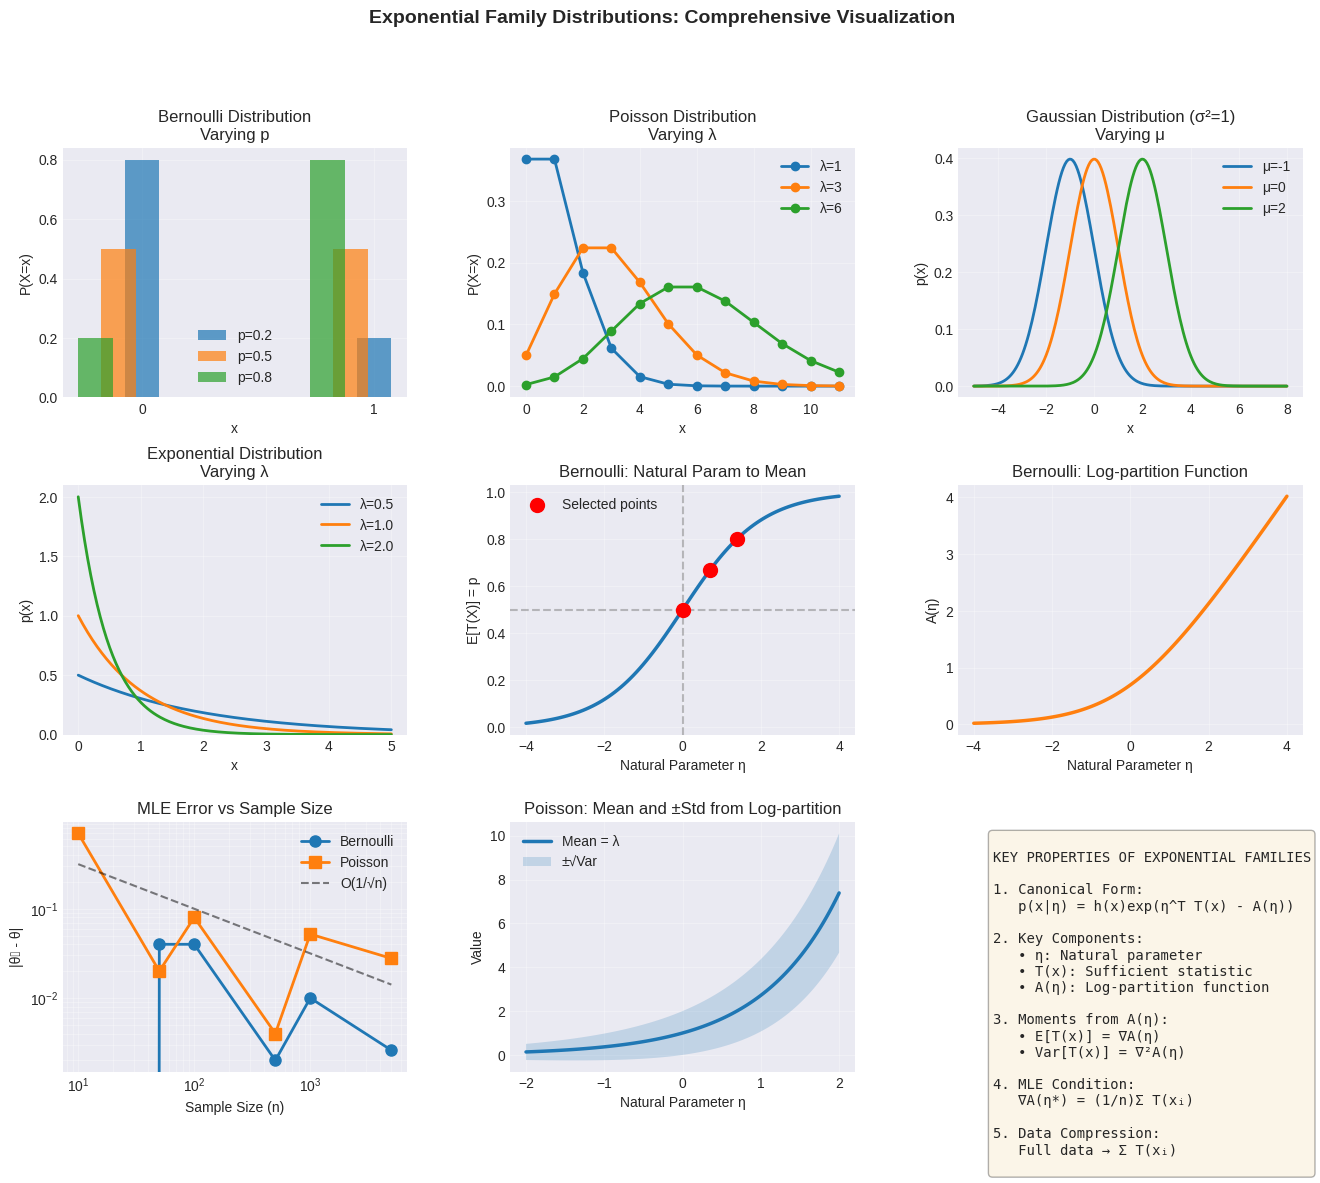

Visualization complete!


In [19]:
# Create comprehensive visualizations of exponential family distributions

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1. Bernoulli Distribution
ax1 = fig.add_subplot(gs[0, 0])
p_values = [0.2, 0.5, 0.8]
x_bernoulli = [0, 1]
for p in p_values:
    pmf = [1-p, p]
    ax1.bar([x - 0.1*p_values.index(p) for x in x_bernoulli], 
            pmf, width=0.15, label=f'p={p}', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('P(X=x)')
ax1.set_title('Bernoulli Distribution\nVarying p')
ax1.set_xticks([0, 1])
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Poisson Distribution
ax2 = fig.add_subplot(gs[0, 1])
x_poisson = np.arange(0, 12)
lambda_values = [1, 3, 6]
for lam in lambda_values:
    pmf = stats.poisson.pmf(x_poisson, lam)
    ax2.plot(x_poisson, pmf, 'o-', label=f'λ={lam}', linewidth=2, markersize=6)
ax2.set_xlabel('x')
ax2.set_ylabel('P(X=x)')
ax2.set_title('Poisson Distribution\nVarying λ')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Gaussian Distribution
ax3 = fig.add_subplot(gs[0, 2])
x_gauss = np.linspace(-5, 8, 200)
mu_values = [-1, 0, 2]
for mu in mu_values:
    pdf = stats.norm.pdf(x_gauss, mu, 1.0)
    ax3.plot(x_gauss, pdf, linewidth=2, label=f'μ={mu}')
ax3.set_xlabel('x')
ax3.set_ylabel('p(x)')
ax3.set_title('Gaussian Distribution (σ²=1)\nVarying μ')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Exponential Distribution
ax4 = fig.add_subplot(gs[1, 0])
x_exp = np.linspace(0, 5, 200)
lambda_exp_values = [0.5, 1.0, 2.0]
for lam_e in lambda_exp_values:
    pdf = stats.expon.pdf(x_exp, scale=1/lam_e)
    ax4.plot(x_exp, pdf, linewidth=2, label=f'λ={lam_e}')
ax4.set_xlabel('x')
ax4.set_ylabel('p(x)')
ax4.set_title('Exponential Distribution\nVarying λ')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(bottom=0)

# 5. Natural Parameters vs Mean (Bernoulli)
ax5 = fig.add_subplot(gs[1, 1])
eta_range_bern = np.linspace(-4, 4, 100)
means_bern = 1 / (1 + np.exp(-eta_range_bern))
ax5.plot(eta_range_bern, means_bern, linewidth=2.5, color='C0')
ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax5.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax5.scatter([0, np.log(2), np.log(1/0.2 - 1)], [0.5, 2/3, 0.8], 
           color='red', s=100, zorder=5, label='Selected points')
ax5.set_xlabel('Natural Parameter η')
ax5.set_ylabel('E[T(X)] = p')
ax5.set_title('Bernoulli: Natural Param to Mean')
ax5.grid(True, alpha=0.3)
ax5.legend()

# 6. Log-partition function (Bernoulli)
ax6 = fig.add_subplot(gs[1, 2])
A_eta_bern = np.log(1 + np.exp(eta_range_bern))
ax6.plot(eta_range_bern, A_eta_bern, linewidth=2.5, color='C1')
ax6.set_xlabel('Natural Parameter η')
ax6.set_ylabel('A(η)')
ax6.set_title('Bernoulli: Log-partition Function')
ax6.grid(True, alpha=0.3)

# 7. Comparison: Parameter recovery from samples
ax7 = fig.add_subplot(gs[2, 0])
sample_sizes = np.array([10, 50, 100, 500, 1000, 5000])
bernoulli_errors = []
poisson_errors = []

true_p = 0.6
true_lambda_for_comparison = 2.5

for n in sample_sizes:
    # Bernoulli
    data_b = np.random.binomial(1, true_p, size=n)
    p_est = np.mean(data_b)
    bernoulli_errors.append(np.abs(p_est - true_p))
    
    # Poisson
    data_p = np.random.poisson(true_lambda_for_comparison, n)
    lambda_est = np.mean(data_p)
    poisson_errors.append(np.abs(lambda_est - true_lambda_for_comparison))

ax7.loglog(sample_sizes, bernoulli_errors, 'o-', linewidth=2, markersize=8, 
          label='Bernoulli')
ax7.loglog(sample_sizes, poisson_errors, 's-', linewidth=2, markersize=8,
          label='Poisson')
ax7.loglog(sample_sizes, 1/np.sqrt(sample_sizes), 'k--', alpha=0.5, 
          label='O(1/√n)')
ax7.set_xlabel('Sample Size (n)')
ax7.set_ylabel('|θ̂ - θ|')
ax7.set_title('MLE Error vs Sample Size')
ax7.legend()
ax7.grid(True, alpha=0.3, which='both')

# 8. Mean and Variance for Poisson
ax8 = fig.add_subplot(gs[2, 1])
eta_range_poisson = np.linspace(-2, 2, 100)
lambda_range = np.exp(eta_range_poisson)
mean_poisson_range = lambda_range
var_poisson_range = lambda_range

ax8.plot(eta_range_poisson, mean_poisson_range, linewidth=2.5, label='Mean = λ')
ax8.fill_between(eta_range_poisson, 
                 mean_poisson_range - var_poisson_range**0.5,
                 mean_poisson_range + var_poisson_range**0.5,
                 alpha=0.2, label='±√Var')
ax8.set_xlabel('Natural Parameter η')
ax8.set_ylabel('Value')
ax8.set_title('Poisson: Mean and ±Std from Log-partition')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Sufficient Statistics Summary
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = """
KEY PROPERTIES OF EXPONENTIAL FAMILIES

1. Canonical Form:
   p(x|η) = h(x)exp(η^T T(x) - A(η))

2. Key Components:
   • η: Natural parameter
   • T(x): Sufficient statistic
   • A(η): Log-partition function

3. Moments from A(η):
   • E[T(x)] = ∇A(η)
   • Var[T(x)] = ∇²A(η)

4. MLE Condition:
   ∇A(η*) = (1/n)Σ T(xᵢ)

5. Data Compression:
   Full data → Σ T(xᵢ)
"""

ax9.text(0.1, 0.95, summary_text, transform=ax9.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Exponential Family Distributions: Comprehensive Visualization', 
            fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("Visualization complete!")


## Summary and Key Takeaways

### What You've Learned

1. **Exponential Family Definition**: Any distribution that can be written in the form $p(x|\eta) = h(x)\exp(\eta^T T(x) - A(\eta))$ is a member of the exponential family.

2. **Universal Framework**: The exponential family includes many common distributions (Bernoulli, Poisson, Gaussian, Exponential), providing a unified way to understand and work with them.

3. **Log-Partition Function**: The function $A(\eta)$ is the key to exponential families:
   - It determines all moments: $E[T(x)] = \nabla A(\eta)$ and $\text{Var}[T(x)] = \nabla^2 A(\eta)$
   - It's the only part that depends on the parameters
   - Understanding one function tells you everything about the distribution

4. **Sufficient Statistics**: The statistic $T(x)$ contains all information needed for parameter estimation:
   - For $n$ samples, only $\sum T(x_i)$ matters
   - This allows massive data compression
   - MLE depends only on the sufficient statistics

5. **Maximum Likelihood Estimation**: For exponential families, MLE reduces to solving:
   $$\nabla A(\eta^{ML}) = \frac{1}{n}\sum_{i=1}^n T(x_i)$$
   
   This has elegant closed-form or easily computed solutions for many distributions.

### Why Exponential Families Matter

- **Theoretical**: They provide a unified mathematical framework for understanding probability distributions
- **Computational**: They enable efficient parameter estimation and inference
- **Practical**: Many real-world applications use exponential family models (Generalized Linear Models, variational inference, etc.)

### Further Reading

- **Generalized Linear Models (GLMs)**: Built on the exponential family framework
- **Variational Inference**: Uses exponential family approximations
- **Maximum Entropy Methods**: Exponential families are maximum entropy distributions given constraints on sufficient statistics

### Related Distributions (also exponential families)

- Gamma distribution
- Beta distribution
- Dirichlet distribution
- Multinomial distribution
- Negative binomial distribution
- Laplace distribution


## Exercises and Practice Problems

### Exercise 1: Beta Distribution as Exponential Family
Verify that the Beta distribution with pdf:
$$p(x|\alpha, \beta) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}$$

Can be written in exponential family form. Identify $T(x)$, $\eta$, and $A(\eta)$.

### Exercise 2: Multivariate Gaussian
The multivariate Gaussian (with known covariance) is also in the exponential family. Write it in canonical form and identify the sufficient statistic.

### Exercise 3: MLE for Gamma Distribution
The Gamma distribution (with known shape parameter $\alpha$) is in the exponential family. Derive the MLE for the rate parameter $\beta$ using the sufficient statistics.

### Exercise 4: Moment Matching
For a Poisson distribution with observed samples, verify that the method of moments and MLE give the same result (they should for exponential families).

### Exercise 5: Log-partition Function
For the logistic distribution:
$$p(x|\mu) = \frac{e^{-(x-\mu)}}{(1+e^{-(x-\mu)})^2}$$

Derive the natural parameter and log-partition function, then verify that you can recover the mean using $\nabla A(\eta)$.

### Exercise 6: Information Geometry
The Fisher Information Matrix (for exponential families) is $\mathcal{I}(\eta) = \nabla^2 A(\eta)$.
- Why is this the same as the variance?
- What does this tell us about the relationship between distribution shape and parameter uncertainty?

## Classification: Exponential Family vs Non-Exponential Family Distributions

Not all distributions can be expressed in the exponential family form. A distribution is part of the exponential family if and only if it can be written as:

$$p(x|\eta) = h(x) \exp(\eta^T T(x) - A(\eta))$$

Below is a comprehensive classification of common probability distributions.

In [22]:
print("\n" + "="*100)
print("COMPREHENSIVE CLASSIFICATION OF DISTRIBUTIONS")
print("="*100)

# Exponential Family Distributions
exp_family_distributions = [
    {
        'Distribution': 'Bernoulli(p)',
        'Domain': 'x ∈ {0, 1}',
        'Natural Parameter': 'η = log(p/(1-p))',
        'Sufficient Statistic': 'T(x) = x',
        'Log-Partition': 'A(η) = log(1 + e^η)',
        'Application': 'Binary classification, coin flips'
    },
    {
        'Distribution': 'Binomial(n, p)',
        'Domain': 'k ∈ {0, 1, ..., n}',
        'Natural Parameter': 'η = log(p/(1-p))',
        'Sufficient Statistic': 'T(k) = k',
        'Log-Partition': 'A(η) = n·log(1 + e^η)',
        'Application': 'Counting successes, number of events'
    },
    {
        'Distribution': 'Poisson(λ)',
        'Domain': 'x ∈ {0, 1, 2, ...}',
        'Natural Parameter': 'η = log(λ)',
        'Sufficient Statistic': 'T(x) = x',
        'Log-Partition': 'A(η) = e^η',
        'Application': 'Count data, rare events'
    },
    {
        'Distribution': 'Gaussian(μ, σ²)',
        'Domain': 'x ∈ ℝ (σ² fixed)',
        'Natural Parameter': 'η = μ/σ²',
        'Sufficient Statistic': 'T(x) = x',
        'Log-Partition': 'A(η) = η²σ²/2',
        'Application': 'Continuous variables, regression'
    },
    {
        'Distribution': 'Exponential(λ)',
        'Domain': 'x ∈ (0, ∞)',
        'Natural Parameter': 'η = -λ',
        'Sufficient Statistic': 'T(x) = x',
        'Log-Partition': 'A(η) = -log(-η)',
        'Application': 'Waiting times, lifetimes'
    },
    {
        'Distribution': 'Gamma(α, β)',
        'Domain': 'x ∈ (0, ∞)',
        'Natural Parameter': 'η = (α-1, -β)ᵀ',
        'Sufficient Statistic': 'T(x) = (log(x), x)ᵀ',
        'Log-Partition': 'A(η) = complex',
        'Application': 'Positive continuous data'
    },
    {
        'Distribution': 'Beta(α, β)',
        'Domain': 'x ∈ (0, 1)',
        'Natural Parameter': 'η = (α-1, β-1)ᵀ',
        'Sufficient Statistic': 'T(x) = (log(x), log(1-x))ᵀ',
        'Log-Partition': 'A(η) = B(α,β)',
        'Application': 'Probabilities, proportions'
    },
    {
        'Distribution': 'Dirichlet(α)',
        'Domain': 'xᵢ ≥ 0, Σxᵢ = 1',
        'Natural Parameter': 'η = α - 1',
        'Sufficient Statistic': 'T(x) = (log x₁, ..., log xₖ)ᵀ',
        'Log-Partition': 'A(η) = B(α)',
        'Application': 'Categorical probabilities'
    },
    {
        'Distribution': 'Multinomial(n, p)',
        'Domain': 'kᵢ ∈ ℕ, Σkᵢ = n',
        'Natural Parameter': 'η = (log p₁, ..., log pₖ)',
        'Sufficient Statistic': 'T(k) = (k₁, ..., kₖ)',
        'Log-Partition': 'A(η) = n·log(Σ e^ηᵢ)',
        'Application': 'Multi-class counts'
    },
    {
        'Distribution': 'Negative Binomial(r, p)',
        'Domain': 'k ∈ {0, 1, 2, ...}',
        'Natural Parameter': 'η = log(p/(1-p))',
        'Sufficient Statistic': 'T(k) = k',
        'Log-Partition': 'A(η) = -r·log(1 - e^η)',
        'Application': 'Overdispersed count data'
    },
    {
        'Distribution': 'Laplace(μ, b)',
        'Domain': 'x ∈ ℝ (b fixed)',
        'Natural Parameter': 'η = (μ/b, -μ/(2b²))',
        'Sufficient Statistic': 'T(x) = (x, |x|)',
        'Log-Partition': 'Complex form',
        'Application': 'Robust regression'
    },
    {
        'Distribution': 'Chi-squared(k)',
        'Domain': 'x ∈ (0, ∞)',
        'Natural Parameter': 'η = -1/2',
        'Sufficient Statistic': 'T(x) = (x, log x)',
        'Log-Partition': 'Complex',
        'Application': 'Hypothesis testing, goodness-of-fit'
    },
    {
        'Distribution': 'Weibull(k, λ)',
        'Domain': 'x ∈ (0, ∞) (k fixed)',
        'Natural Parameter': 'η = (1, -λᵏ)',
        'Sufficient Statistic': 'T(x) = (x^k, x)',
        'Log-Partition': 'Complex',
        'Application': 'Reliability, survival analysis'
    }
]

# Non-Exponential Family Distributions
non_exp_family_distributions = [
    {
        'Distribution': 'Uniform(a, b)',
        'Domain': 'x ∈ [a, b]',
        'Reason': 'Support depends on parameters. Cannot write in form h(x)exp(...)',
        'Example Issue': 'p(x) = 1/(b-a) has bounded support; boundary points are parameters',
        'Alternative': 'Can be extended to exponential family by fixing bounds'
    },
    {
        'Distribution': 'Beta-Binomial',
        'Domain': 'k ∈ {0, ..., n}',
        'Reason': 'Mixture of Binomial and Beta; not expressible in canonical form',
        'Example Issue': 'Marginalizing over continuous parameter breaks exponential family form',
        'Alternative': 'Can treat as hierarchical model'
    },
    {
        'Distribution': 'Student\'s t-distribution',
        'Domain': 'x ∈ ℝ',
        'Reason': 'Heavy tails require non-canonical form; support depends on degrees of freedom',
        'Example Issue': 'Integral representations cannot factorize into exp form',
        'Alternative': 'Scale mixtures of Gaussians (hierarchical)'
    },
    {
        'Distribution': 'Cauchy',
        'Domain': 'x ∈ ℝ',
        'Reason': 'No mean or variance; location parameter appears non-linearly in denominator',
        'Example Issue': 'p(x) ∝ 1/(1 + ((x-μ)/σ)²) cannot be written in exp family form',
        'Alternative': 'Ratio of Gaussians'
    },
    {
        'Distribution': 'Log-Normal',
        'Domain': 'x ∈ (0, ∞)',
        'Reason': 'Transformation breaks exponential family structure',
        'Example Issue': 'Cannot separate x and parameters in exponential',
        'Alternative': 'Can model log(x) as Gaussian (exponential family)'
    },
    {
        'Distribution': 'Pareto',
        'Domain': 'x ≥ x₀',
        'Reason': 'Support depends on parameters (Pareto: x ≥ m)',
        'Example Issue': 'Indicator function on (x ≥ m) ties support to parameter',
        'Alternative': 'Can reparameterize with fixed lower bound'
    },
    {
        'Distribution': 'Power-Law',
        'Domain': 'x ∈ (a, b)',
        'Reason': 'Bounded support with parameter-dependent boundaries',
        'Example Issue': 'Cannot write p(x|θ) = h(x)exp(f(x,θ)) with fixed support',
        'Alternative': 'Generalized Pareto (special case sometimes works)'
    },
    {
        'Distribution': 'Mixture Distributions',
        'Domain': 'Varies',
        'Reason': 'Mixtures of exponential families are NOT exponential families',
        'Example Issue': 'p(x) = Σ wₖ pₖ(x|θₖ); logarithm of sum ≠ sum of logarithms',
        'Alternative': 'Hierarchical models (latent indicators)'
    },
    {
        'Distribution': 'Gumbel (Extreme Value)',
        'Domain': 'x ∈ ℝ',
        'Reason': 'Parameter appears in exponent without clean factorization',
        'Example Issue': 'p(x) = (1/σ)exp(-(x-μ)/σ)exp(-exp(-(x-μ)/σ))',
        'Alternative': 'Can be written in exponential family with different parameterization'
    },
    {
        'Distribution': 'Logistic',
        'Domain': 'x ∈ ℝ',
        'Reason': 'Actually CAN be expressed as exponential family (special case of skew-logistic)',
        'Example Issue': 'Some sources debate this - depends on parameterization',
        'Alternative': 'Typically written in exp family form'
    }
]

# Display Exponential Family Distributions Table
print("\n" + "█"*100)
print("✓ DISTRIBUTIONS THAT ARE EXPONENTIAL FAMILIES")
print("█"*100 + "\n")

df_exp_family = pd.DataFrame(exp_family_distributions)
print(df_exp_family.to_string(index=False))

print("\n\nTotal Exponential Family Distributions:", len(exp_family_distributions))

# Display Non-Exponential Family Distributions Table
print("\n\n" + "█"*100)
print("✗ DISTRIBUTIONS THAT ARE NOT EXPONENTIAL FAMILIES")
print("█"*100 + "\n")

df_non_exp = pd.DataFrame(non_exp_family_distributions)
print(df_non_exp.to_string(index=False))

print("\n\nTotal Non-Exponential Family Distributions:", len(non_exp_family_distributions))

# Summary and Key Insights
print("\n\n" + "="*100)
print("KEY INSIGHTS")
print("="*100)

insights_text = """
1. WHY EXPONENTIAL FAMILIES MATTER:
   • Most standard statistical distributions ARE exponential families
   • Exponential family framework enables unified inference algorithms
   • Variational inference, expectation-maximization, and other methods leverage this structure

2. SUPPORT DEPENDENCY:
   • When support (domain) depends on parameters → usually NOT exponential family
   • Example: Uniform(a,b) has support [a,b]; endpoints are parameters
   • Exponential families typically have support independent of parameters

3. PARAMETER STRUCTURE:
   • Parameters must appear in specific form: exp(η^T T(x) - A(η))
   • If parameters appear non-linearly in denominator or transcendental functions → likely not exponential family
   • Example: Cauchy has parameter in denominator: 1/(1 + ((x-μ)/σ)²)

4. MIXTURE DISTRIBUTIONS:
   • Mixtures of exponential families are NOT exponential families
   • Reason: log(Σ...) ≠ Σ log(...)
   • However, can use EM algorithm with latent mixture indicators

5. TRANSFORMATIONS:
   • Simple transformations (like log) can sometimes take non-exponential to exponential family
   • Example: Log-Normal → Model log(X) as Gaussian (exponential family)
   • Important for change-of-variables in modeling

6. PARAMETRIZATION MATTERS:
   • Same distribution may be exponential family under one parametrization but not another
   • Example: Uniform can sometimes be extended to exponential family framework
   • Always check the specific parameterization being used

7. PRACTICAL IMPLICATIONS:
   • For exponential families: Closed-form MLEs often exist
   • For non-exponential: Need numerical optimization
   • For exponential families: Sufficient statistics can compress data
   • For non-exponential: Must work with full data
"""

print(insights_text)

# Create a comparison summary
print("\n" + "="*100)
print("PROPERTIES COMPARISON")
print("="*100 + "\n")

comparison_data = {
    'Property': [
        'Sufficient Statistics',
        'MLE Form',
        'Mean/Variance',
        'Moments',
        'Conjugate Priors',
        'Variational Inference',
        'Data Compression',
        'Log-likelihood'
    ],
    'Exponential Family': [
        'T(x) completely summarizes data',
        'Often has closed form: ∇A(η*) = (1/n)ΣT(xᵢ)',
        'E[T(x)] = ∇A(η), Var[T(x)] = ∇²A(η)',
        'All moments derivable from A(η)',
        'Exist and are well-understood',
        'Natural mean-field approximations possible',
        'Σ T(xᵢ) << individual data points',
        'Separable: Σ[ηᵀT(xᵢ) - A(η) + log h(xᵢ)]'
    ],
    'Non-Exponential Family': [
        'May not exist; full data needed',
        'Usually requires numerical optimization',
        'No standard formula',
        'Computed via integration/simulation',
        'Generally do not exist',
        'More complex approximations needed',
        'Full data often necessary',
        'No standard decomposition'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("\n" + "="*100)



COMPREHENSIVE CLASSIFICATION OF DISTRIBUTIONS

████████████████████████████████████████████████████████████████████████████████████████████████████
✓ DISTRIBUTIONS THAT ARE EXPONENTIAL FAMILIES
████████████████████████████████████████████████████████████████████████████████████████████████████

           Distribution               Domain         Natural Parameter          Sufficient Statistic          Log-Partition                          Application
           Bernoulli(p)           x ∈ {0, 1}          η = log(p/(1-p))                      T(x) = x    A(η) = log(1 + e^η)    Binary classification, coin flips
         Binomial(n, p)   k ∈ {0, 1, ..., n}          η = log(p/(1-p))                      T(k) = k  A(η) = n·log(1 + e^η) Counting successes, number of events
             Poisson(λ)   x ∈ {0, 1, 2, ...}                η = log(λ)                      T(x) = x             A(η) = e^η              Count data, rare events
        Gaussian(μ, σ²)     x ∈ ℝ (σ² fixed)               

## Bonus: Binomial Distribution as Exponential Family

The binomial distribution is a classic example of an exponential family distribution, and it closely relates to the Bernoulli distribution we studied earlier.

In [20]:
print("BINOMIAL DISTRIBUTION AS EXPONENTIAL FAMILY")
print("=" * 80)

print("\n1. MATHEMATICAL DERIVATION")
print("-" * 80)

print("\nBinomial Distribution:")
print("  P(X=k|n,p) = C(n,k) p^k (1-p)^(n-k)")
print("\nStep 1: Factor out the binomial coefficient")
print("  = C(n,k) exp[k·log(p) + (n-k)·log(1-p)]")
print("\nStep 2: Simplify the exponent")
print("  = C(n,k) exp[k·log(p/(1-p)) + n·log(1-p)]")
print("\nStep 3: Identify exponential family components:")
print("  ✓ h(k) = C(n,k)              [base measure]")
print("  ✓ η = log(p/(1-p))           [natural parameter]")
print("  ✓ T(k) = k                   [sufficient statistic]")
print("  ✓ A(η) = n·log(1 + e^η)      [log-partition function]")

print("\nCanonical Form:")
print("  P(X=k|η,n) = C(n,k) exp(η·k - A(η))")

# Relationship to Bernoulli
print("\n\n2. RELATIONSHIP TO BERNOULLI")
print("-" * 80)
print("\nBernoulli (n=1): Special case of Binomial")
print("  P(X=x|p) = p^x (1-p)^(1-x)  ← Binomial with n=1")
print("\nBinomial (n>1): Sum of n independent Bernoulli trials")
print("  X ~ Binomial(n,p) means:")
print("  X = sum of n i.i.d. Bernoulli(p) random variables")
print("\nSame natural parameter!")
print("  Bernoulli:  η = log(p/(1-p))")
print("  Binomial:   η = log(p/(1-p))  ← Identical!")

# Implementation
print("\n\n3. IMPLEMENTATION: BINOMIAL AS EXPONENTIAL FAMILY")
print("-" * 80)

class BinomialExponentialFamily(ExponentialFamilyExample):
    """Binomial distribution as exponential family"""
    
    def __init__(self, n):
        super().__init__(f"Binomial(n={n})")
        self.n = n
    
    def log_partition(self, eta):
        """A(η) = n·log(1 + exp(η))"""
        return self.n * np.log(1 + np.exp(eta))
    
    def sufficient_stat(self, k):
        """T(k) = k (number of successes)"""
        return k
    
    def eta_from_p(self, p):
        """Convert probability p to natural parameter η"""
        return np.log(p / (1 - p))
    
    def p_from_eta(self, eta):
        """Convert natural parameter η to probability p"""
        return 1 / (1 + np.exp(-eta))
    
    def pmf(self, k, eta):
        """Probability mass function in canonical form"""
        log_partition = self.log_partition(eta)
        return stats.binom.pmf(k, self.n, self.p_from_eta(eta))

# Numerical Example 1: n=10, p=0.6
print("\nExample 1: Binomial(n=10, p=0.6)")
print("-" * 40)
binom_ef = BinomialExponentialFamily(n=10)
p = 0.6
eta_binom = binom_ef.eta_from_p(p)

print(f"Probability p = {p}")
print(f"Natural parameter η = log(p/(1-p)) = {eta_binom:.4f}")
print(f"\nLog-partition A(η) = n·log(1 + e^η)")
print(f"  = 10·log(1 + e^{eta_binom:.4f})")
print(f"  = {binom_ef.log_partition(eta_binom):.4f}")

# Compute mean and variance
mean_binom = binom_ef.mean_from_log_partition(np.array([eta_binom]))[0]
var_hessian = numerical_hessian(binom_ef.log_partition, np.array([eta_binom]))[0, 0]

print(f"\nMean from E[T(k)] = ∇A(η):")
print(f"  Computed: {mean_binom:.4f}")
print(f"  Expected: n·p = 10·{p} = {10*p:.4f}")

print(f"\nVariance from Var[T(k)] = ∇²A(η):")
print(f"  Computed: {var_hessian:.4f}")
print(f"  Expected: n·p·(1-p) = 10·{p}·{1-p} = {10*p*(1-p):.4f}")

# Numerical Example 2: Different values of n
print("\n\nExample 2: Comparison for Different n")
print("-" * 40)

p_compare = 0.7
n_values = [1, 5, 10, 20]

comparison_data = []
for n in n_values:
    binom_n = BinomialExponentialFamily(n)
    eta = binom_n.eta_from_p(p_compare)
    A_eta = binom_n.log_partition(eta)
    
    mean_computed = binom_n.mean_from_log_partition(np.array([eta]))[0]
    expected_mean = n * p_compare
    expected_var = n * p_compare * (1 - p_compare)
    
    comparison_data.append({
        'n': n,
        'η': f'{eta:.4f}',
        'A(η)': f'{A_eta:.4f}',
        'E[k]': f'{mean_computed:.4f}',
        'E[k] theoretical': f'{expected_mean:.4f}',
        'Var[k] theoretical': f'{expected_var:.4f}'
    })

df_binomial_comparison = pd.DataFrame(comparison_data)
print(df_binomial_comparison.to_string(index=False))

print(f"\nNote: When n=1, Binomial becomes Bernoulli!")

# Sufficient Statistics
print("\n\n4. SUFFICIENT STATISTICS FOR BINOMIAL")
print("-" * 80)

print("\nFor i.i.d. samples X₁, X₂, ..., Xₙ ~ Binomial(n,p):")
print("  Sufficient Statistic: Σ Xᵢ")
print("\nThis means:")
print("  • The total count of successes summarizes all information")
print("  • MLE depends only on Σ Xᵢ, not on individual values")
print("  • Data compression: n random variables → 1 number")

# Generate samples and demonstrate
np.random.seed(42)
n_trials = 10
n_experiments = 5
p_true = 0.65

samples = np.random.binomial(n_trials, p_true, n_experiments)
total_successes = np.sum(samples)
empirical_mean = total_successes / n_experiments

print(f"\nNumerical Example:")
print(f"  True p = {p_true}")
print(f"  {n_experiments} experiments with n={n_trials} trials each")
print(f"  Results: {samples}")
print(f"  Sufficient statistic (Σ Xᵢ): {total_successes}")
print(f"  Empirical mean: {empirical_mean/n_trials:.4f}")
print(f"  Expected mean: {p_true:.4f}")

# MLE for Binomial
print("\n\n5. MAXIMUM LIKELIHOOD ESTIMATION")
print("-" * 80)

print("\nFor Binomial with n known:")
print("  MLE for p satisfies: ∇A(η*) = (1/N)·Σ Xᵢ")
print("\nWhere N is the number of experiments")
print("  (1/N)·Σ Xᵢ = empirical mean per trial")
print("\nFor Binomial:")
print("  n·p̂ = (1/N)·Σ Xᵢ")
print("  p̂ = (1/N)·Σ Xᵢ / n = (total successes) / (total trials)")

# Example MLE
N = 100
n_per_experiment = 5
true_p_mle = 0.4

binomial_data = np.random.binomial(n_per_experiment, true_p_mle, N)
total_successes_mle = np.sum(binomial_data)
p_mle_computed = total_successes_mle / (N * n_per_experiment)

print(f"\nExample: N={N} experiments with n={n_per_experiment} trials each")
print(f"  True p = {true_p_mle}")
print(f"  Total successes: {total_successes_mle}")
print(f"  Total trials: {N * n_per_experiment}")
print(f"  MLE: p̂ = {total_successes_mle}/{N * n_per_experiment} = {p_mle_computed:.4f}")


BINOMIAL DISTRIBUTION AS EXPONENTIAL FAMILY

1. MATHEMATICAL DERIVATION
--------------------------------------------------------------------------------

Binomial Distribution:
  P(X=k|n,p) = C(n,k) p^k (1-p)^(n-k)

Step 1: Factor out the binomial coefficient
  = C(n,k) exp[k·log(p) + (n-k)·log(1-p)]

Step 2: Simplify the exponent
  = C(n,k) exp[k·log(p/(1-p)) + n·log(1-p)]

Step 3: Identify exponential family components:
  ✓ h(k) = C(n,k)              [base measure]
  ✓ η = log(p/(1-p))           [natural parameter]
  ✓ T(k) = k                   [sufficient statistic]
  ✓ A(η) = n·log(1 + e^η)      [log-partition function]

Canonical Form:
  P(X=k|η,n) = C(n,k) exp(η·k - A(η))


2. RELATIONSHIP TO BERNOULLI
--------------------------------------------------------------------------------

Bernoulli (n=1): Special case of Binomial
  P(X=x|p) = p^x (1-p)^(1-x)  ← Binomial with n=1

Binomial (n>1): Sum of n independent Bernoulli trials
  X ~ Binomial(n,p) means:
  X = sum of n i.i.d. Ber

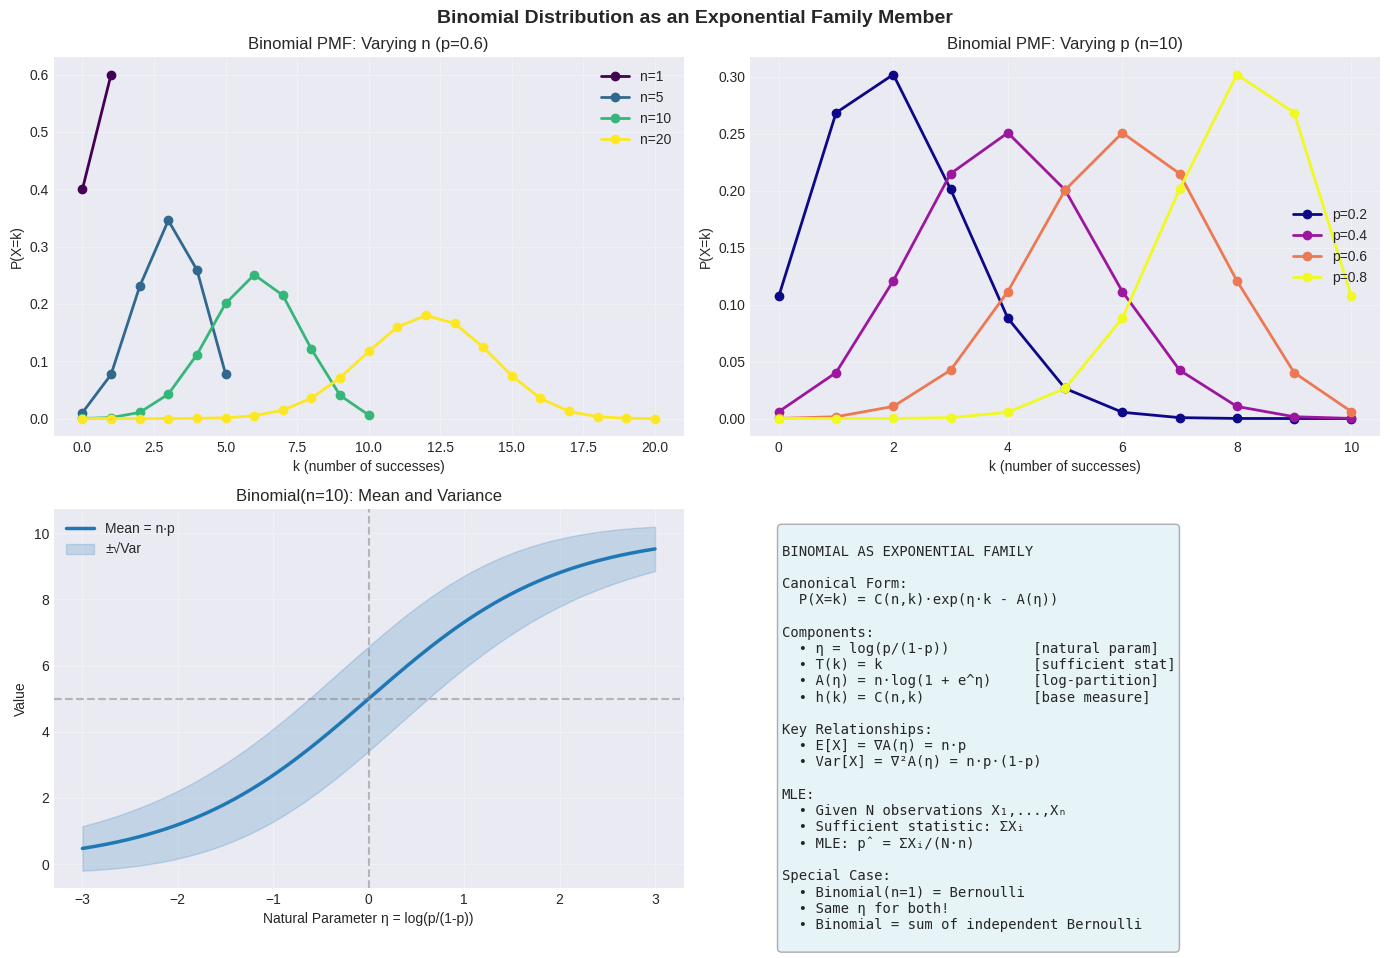


Visualization complete!


In [21]:
# Visualize Binomial as Exponential Family

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: PMF for different n values (fixed p)
ax = axes[0, 0]
p_fixed = 0.6
n_vals = [1, 5, 10, 20]
colors = plt.cm.viridis(np.linspace(0, 1, len(n_vals)))

for i, n in enumerate(n_vals):
    x = np.arange(0, n+1)
    pmf = stats.binom.pmf(x, n, p_fixed)
    ax.plot(x, pmf, 'o-', label=f'n={n}', color=colors[i], linewidth=2, markersize=6)

ax.set_xlabel('k (number of successes)')
ax.set_ylabel('P(X=k)')
ax.set_title(f'Binomial PMF: Varying n (p={p_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: PMF for different p values (fixed n)
ax = axes[0, 1]
n_fixed = 10
p_vals = [0.2, 0.4, 0.6, 0.8]
colors = plt.cm.plasma(np.linspace(0, 1, len(p_vals)))

for i, p in enumerate(p_vals):
    x = np.arange(0, n_fixed+1)
    pmf = stats.binom.pmf(x, n_fixed, p)
    ax.plot(x, pmf, 'o-', label=f'p={p}', color=colors[i], linewidth=2, markersize=6)

ax.set_xlabel('k (number of successes)')
ax.set_ylabel('P(X=k)')
ax.set_title(f'Binomial PMF: Varying p (n={n_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Mean and Variance vs η
ax = axes[1, 0]
eta_range = np.linspace(-3, 3, 200)
n_for_plot = 10

p_range = 1 / (1 + np.exp(-eta_range))
mean_range = n_for_plot * p_range
var_range = n_for_plot * p_range * (1 - p_range)

ax.plot(eta_range, mean_range, linewidth=2.5, label='Mean = n·p', color='C0')
ax.fill_between(eta_range, 
               mean_range - np.sqrt(var_range),
               mean_range + np.sqrt(var_range),
               alpha=0.2, label='±√Var', color='C0')
ax.set_xlabel('Natural Parameter η = log(p/(1-p))')
ax.set_ylabel('Value')
ax.set_title(f'Binomial(n={n_for_plot}): Mean and Variance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=n_for_plot/2, color='gray', linestyle='--', alpha=0.5)

# Plot 4: Comparison table as text
ax = axes[1, 1]
ax.axis('off')

comparison_text = """
BINOMIAL AS EXPONENTIAL FAMILY

Canonical Form:
  P(X=k) = C(n,k)·exp(η·k - A(η))

Components:
  • η = log(p/(1-p))          [natural param]
  • T(k) = k                  [sufficient stat]
  • A(η) = n·log(1 + e^η)     [log-partition]
  • h(k) = C(n,k)             [base measure]

Key Relationships:
  • E[X] = ∇A(η) = n·p
  • Var[X] = ∇²A(η) = n·p·(1-p)

MLE:
  • Given N observations X₁,...,Xₙ
  • Sufficient statistic: ΣXᵢ
  • MLE: p̂ = ΣXᵢ/(N·n)

Special Case:
  • Binomial(n=1) = Bernoulli
  • Same η for both!
  • Binomial = sum of independent Bernoulli
"""

ax.text(0.05, 0.95, comparison_text, transform=ax.transAxes,
       fontsize=10, verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.suptitle('Binomial Distribution as an Exponential Family Member', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nVisualization complete!")
